# Anomaly detection 2 - Isolation Forest

In [ ]:
!gdown 1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg

Downloading...
From: https://drive.google.com/uc?id=1c6cjIULb3-fjyaVITdui_AFcKMz_lxlg
To: /content/Data: AnomalyDetection.csv
100% 33.0k/33.0k [00:00<00:00, 55.0MB/s]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (12,8)

In [ ]:
df = pd.read_csv('Data: AnomalyDetection.csv')
df.head()

,Mileage,Price
0,54.282388,67.967708
1,17.331911,70.023637
2,36.548113,68.080455
3,42.567541,71.058755
4,5.608853,57.822432


In [ ]:
df.columns

Index(['Mileage', 'Price'], dtype='object')

In [ ]:
df.describe()

,Mileage,Price
count,908.000000,908.000000
mean,45.869736,77.555036
std,30.598219,19.275677
min,1.398964,20.000000
25%,25.415487,64.435773
50%,34.599453,73.550501
75%,49.862529,88.939217
max,128.604249,141.201890


Text(0, 0.5, 'Price')

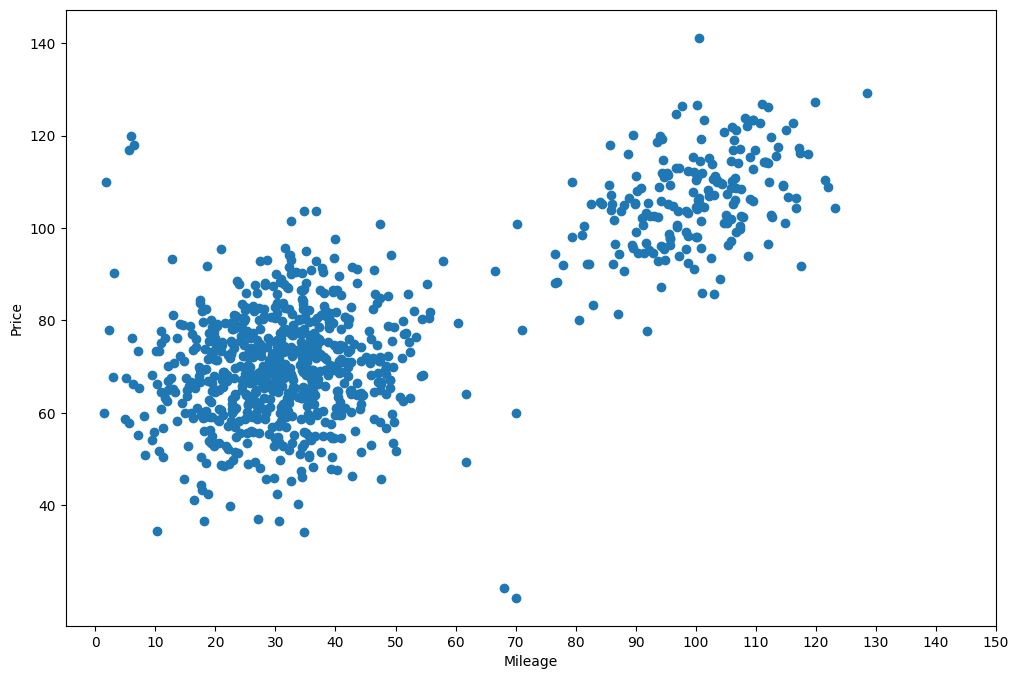

In [ ]:
plt.scatter(df.Mileage, df.Price)
plt.yticks(np.arange(40,160,20))
plt.xticks(np.arange(0,160,10))
plt.xlabel('Mileage')
plt.ylabel('Price')

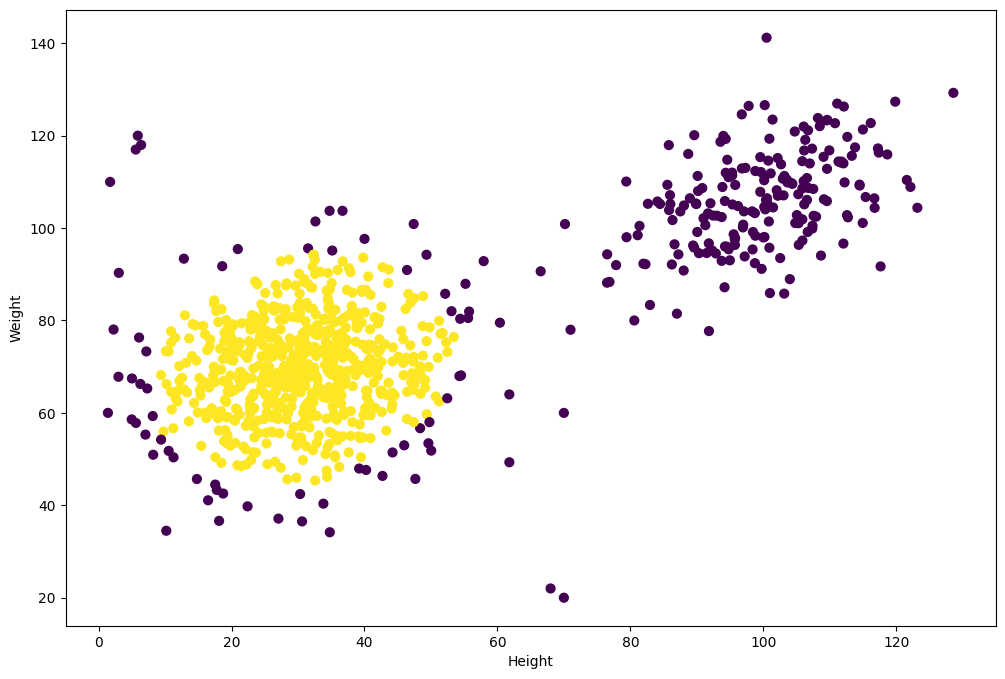

CPU times: user 1.26 s, sys: 28.3 ms, total: 1.29 s
Wall time: 3.31 s


In [ ]:
%%time
# EllipticEnvelope
# 😟It cannot be used non-unimodal data😟
# It is specifically for multivariate gaussians
from sklearn.covariance import EllipticEnvelope
cov = EllipticEnvelope(random_state=0,contamination=0.3).fit(df[['Mileage', 'Price']])
df['is_outlier_ee'] = cov.predict(df[['Mileage', 'Price']])
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_ee'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

[-1]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(


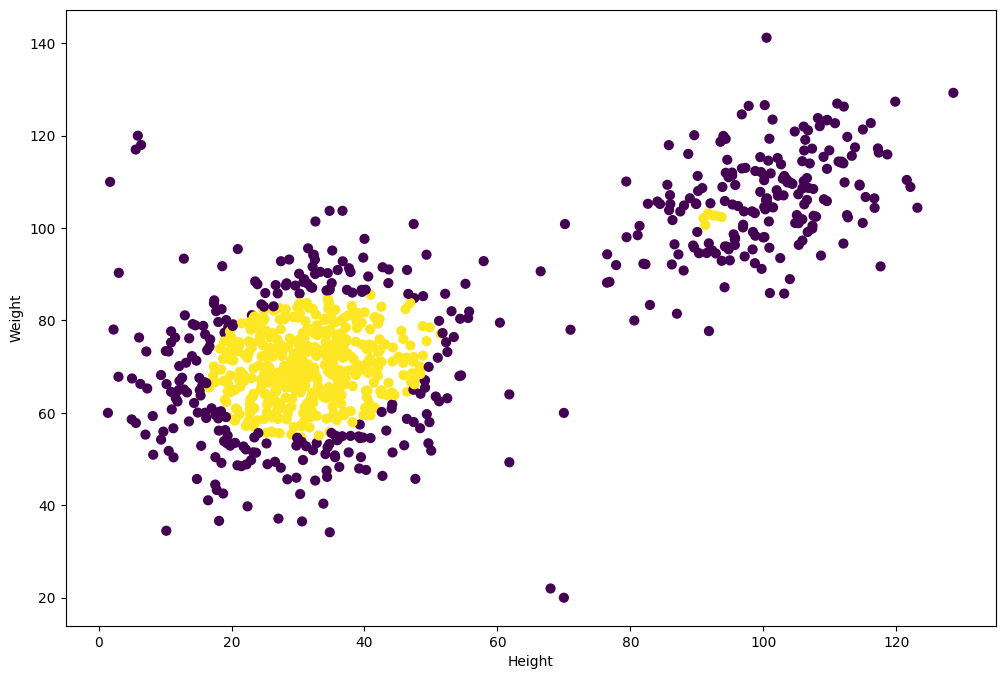

CPU times: user 443 ms, sys: 37.7 ms, total: 481 ms
Wall time: 705 ms


In [ ]:
%%time
# OneClassSVM
from sklearn.svm import OneClassSVM
clf = OneClassSVM().fit(df[['Mileage', 'Price']])
print(clf.predict([[50,50]])) # can predict/offline
df['is_outlier_ie'] = clf.predict(df[['Mileage', 'Price']])
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_ie'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


[-1]


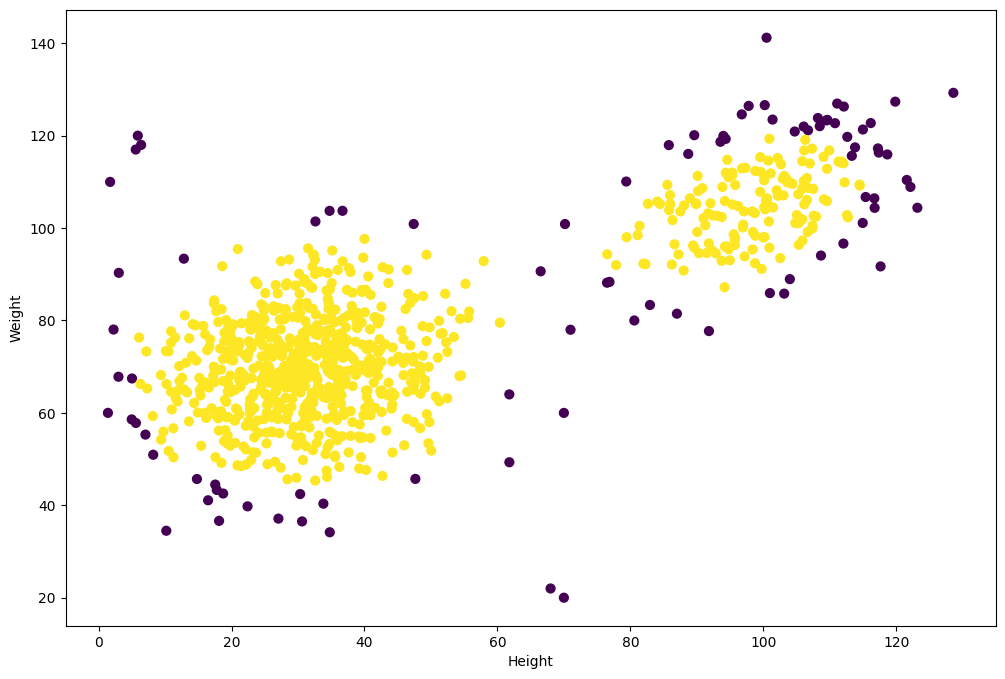

CPU times: user 5.8 s, sys: 95.6 ms, total: 5.9 s
Wall time: 8.67 s


In [ ]:
%%time
# IsolationForest
from sklearn.ensemble import IsolationForest
clf = IsolationForest(random_state=0,contamination=0.1, n_estimators=1000).fit(df[['Mileage', 'Price']])
print(clf.predict([[50,50]])) # can predict/offline
df['is_outlier_ie'] = clf.predict(df[['Mileage', 'Price']])
plt.scatter(df.Mileage, df.Price, s=40, c=df['is_outlier_ie'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

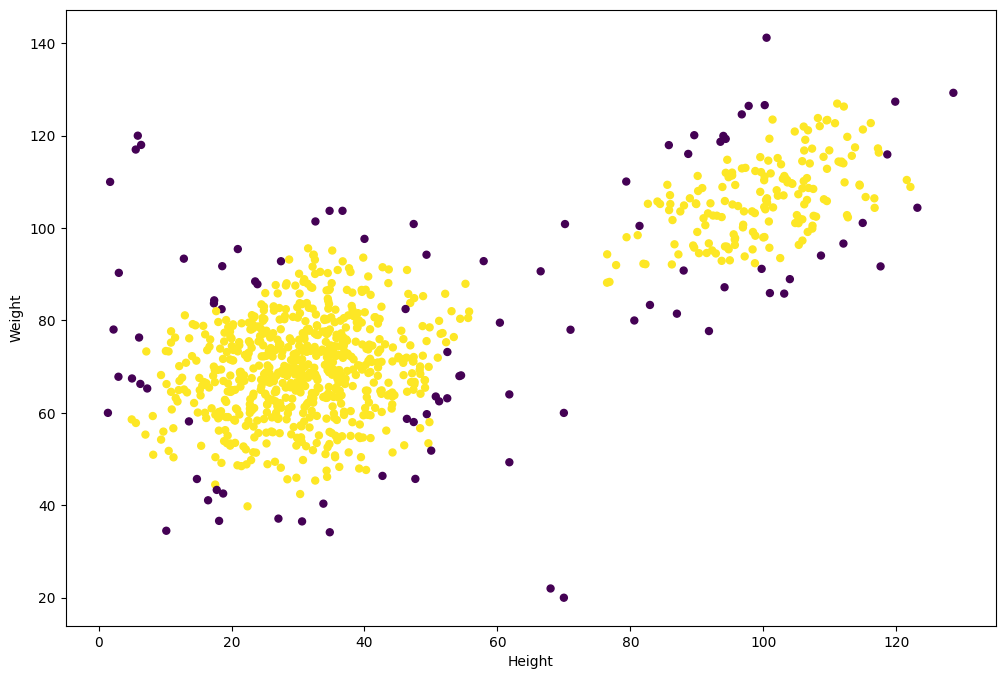

CPU times: user 370 ms, sys: 53.9 ms, total: 424 ms
Wall time: 782 ms


In [ ]:
%%time
# LocalOutlierFactor: https://dl.acm.org/doi/pdf/10.1145/335191.335388
from sklearn.neighbors import LocalOutlierFactor
df['is_outlier_lof'] = LocalOutlierFactor(contamination=0.1, n_neighbors=10).fit_predict(df[['Mileage', 'Price']])
# no predict as it will require re-computation of all LOFs
plt.scatter(df.Mileage, df.Price, s=25, c=df['is_outlier_lof'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()